In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("Crop recommendation dataset (1).csv")
df

,CROPS,TYPE_OF_CROP,SOIL,SEASON,SOWN,HARVESTED,WATER_SOURCE,SOIL_PH,SOIL_PH_HIGH,CROPDURATION,...,WATERREQUIRED,WATERREQUIRED_MAX,RELATIVE_HUMIDITY,RELATIVE_HUMIDITY_MAX,N,N_MAX,P,P_MAX,K,K_MAX
0,rice,cereals,Alluvial soil,kharif,Jun,Sep,irrigated,7.6,8.0,116.9,...,2462.3,2500,73.8,80,82.4,100,40.7,60,42.2,60
1,rice,cereals,Loamy soil,kharif,Jul,Oct,rainfed,6.2,8.0,117.9,...,1237.5,2500,60.9,80,90.5,100,51.3,60,46.2,60
2,rice,cereals,Clay soil,kharif,Jun,Sep,irrigated,6.7,8.0,117.7,...,1075.1,2500,67.5,80,86.2,100,50.7,60,44.4,60
3,rice,cereals,Alluvial soil,kharif,Jul,Oct,rainfed,6.1,8.0,149.8,...,1549.9,2500,73.6,80,91.3,100,51.3,60,44.5,60
4,rice,cereals,Loamy soil,kharif,Jun,Sep,irrigated,8.0,8.0,131.7,...,1306.4,2500,60.3,80,81.3,100,48.6,60,51.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56995,small onion,bulbvegetables,sandy Loamy soil,Zaid,Mar,Mar,rainfed,6.2,7.0,86.6,...,701.9,750,66.0,75,73.8,100,44.5,60,57.9,60
56996,small onion,bulbvegetables,sandy Loamy soil,Zaid,Apr,Apr,irrigated,6.4,7.0,70.3,...,653.5,750,66.2,75,72.4,100,50.5,60,55.1,60
56997,small onion,bulbvegetables,sandy Loamy soil,Zaid,May,May,rainfed,6.4,7.0,86.3,...,743.3,750,65.6,75,70.5,100,59.8,60,58.5,60
56998,small onion,bulbvegetables,sandy Loamy soil,Zaid,Jun,Jun,irrigated,6.2,7.0,89.1,...,736.8,750,74.2,75,66.8,100,40.2,60,55.3,60


# EXPLORATORY  DATA ANALYSIS

In [3]:
print(df.shape)
print(df.head())

(57000, 23)
  CROPS TYPE_OF_CROP           SOIL  SEASON SOWN HARVESTED WATER_SOURCE  \
0  rice      cereals  Alluvial soil  kharif  Jun       Sep    irrigated   
1  rice      cereals     Loamy soil  kharif  Jul       Oct      rainfed   
2  rice      cereals      Clay soil  kharif  Jun       Sep    irrigated   
3  rice      cereals  Alluvial soil  kharif  Jul       Oct      rainfed   
4  rice      cereals     Loamy soil  kharif  Jun       Sep    irrigated   

   SOIL_PH  SOIL_PH_HIGH  CROPDURATION  ...  WATERREQUIRED  WATERREQUIRED_MAX  \
0      7.6           8.0         116.9  ...         2462.3               2500   
1      6.2           8.0         117.9  ...         1237.5               2500   
2      6.7           8.0         117.7  ...         1075.1               2500   
3      6.1           8.0         149.8  ...         1549.9               2500   
4      8.0           8.0         131.7  ...         1306.4               2500   

   RELATIVE_HUMIDITY  RELATIVE_HUMIDITY_MAX     N 

In [4]:
print(df.columns)

Index(['CROPS', 'TYPE_OF_CROP', 'SOIL', 'SEASON', 'SOWN', 'HARVESTED',
       'WATER_SOURCE', 'SOIL_PH', 'SOIL_PH_HIGH', 'CROPDURATION',
       'CROPDURATION_MAX', 'TEMP', 'MAX_TEMP', 'WATERREQUIRED',
       'WATERREQUIRED_MAX', 'RELATIVE_HUMIDITY', 'RELATIVE_HUMIDITY_MAX', 'N',
       'N_MAX', 'P', 'P_MAX', 'K', 'K_MAX'],
      dtype='object')


In [5]:
df.drop('TYPE_OF_CROP', axis=1, inplace=True)
df.drop('SOWN', axis=1, inplace=True)
df.drop('HARVESTED', axis=1, inplace=True)
df.drop('SOIL_PH_HIGH', axis=1, inplace=True)
df.drop('CROPDURATION_MAX', axis=1, inplace=True)
df.drop('MAX_TEMP', axis=1, inplace=True)
df.drop('WATERREQUIRED_MAX', axis=1, inplace=True)
df.drop('RELATIVE_HUMIDITY_MAX', axis=1, inplace=True)
df.drop('N_MAX', axis=1, inplace=True)
df.drop('P_MAX', axis=1, inplace=True)
df.drop('K_MAX', axis=1, inplace=True)



In [6]:
df

,CROPS,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
0,rice,Alluvial soil,kharif,irrigated,7.6,116.9,26.9,2462.3,73.8,82.4,40.7,42.2
1,rice,Loamy soil,kharif,rainfed,6.2,117.9,35.8,1237.5,60.9,90.5,51.3,46.2
2,rice,Clay soil,kharif,irrigated,6.7,117.7,34.9,1075.1,67.5,86.2,50.7,44.4
3,rice,Alluvial soil,kharif,rainfed,6.1,149.8,28.3,1549.9,73.6,91.3,51.3,44.5
4,rice,Loamy soil,kharif,irrigated,8.0,131.7,26.3,1306.4,60.3,81.3,48.6,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...
56995,small onion,sandy Loamy soil,Zaid,rainfed,6.2,86.6,21.7,701.9,66.0,73.8,44.5,57.9
56996,small onion,sandy Loamy soil,Zaid,irrigated,6.4,70.3,20.5,653.5,66.2,72.4,50.5,55.1
56997,small onion,sandy Loamy soil,Zaid,rainfed,6.4,86.3,18.6,743.3,65.6,70.5,59.8,58.5
56998,small onion,sandy Loamy soil,Zaid,irrigated,6.2,89.1,23.1,736.8,74.2,66.8,40.2,55.3


In [7]:
df.head()

,CROPS,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
0,rice,Alluvial soil,kharif,irrigated,7.6,116.9,26.9,2462.3,73.8,82.4,40.7,42.2
1,rice,Loamy soil,kharif,rainfed,6.2,117.9,35.8,1237.5,60.9,90.5,51.3,46.2
2,rice,Clay soil,kharif,irrigated,6.7,117.7,34.9,1075.1,67.5,86.2,50.7,44.4
3,rice,Alluvial soil,kharif,rainfed,6.1,149.8,28.3,1549.9,73.6,91.3,51.3,44.5
4,rice,Loamy soil,kharif,irrigated,8.0,131.7,26.3,1306.4,60.3,81.3,48.6,51.0


In [8]:
df.tail()

,CROPS,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
56995,small onion,sandy Loamy soil,Zaid,rainfed,6.2,86.6,21.7,701.9,66.0,73.8,44.5,57.9
56996,small onion,sandy Loamy soil,Zaid,irrigated,6.4,70.3,20.5,653.5,66.2,72.4,50.5,55.1
56997,small onion,sandy Loamy soil,Zaid,rainfed,6.4,86.3,18.6,743.3,65.6,70.5,59.8,58.5
56998,small onion,sandy Loamy soil,Zaid,irrigated,6.2,89.1,23.1,736.8,74.2,66.8,40.2,55.3
56999,small onion,sandy Loamy soil,Zaid,rainfed,6.7,90.0,20.6,726.0,72.1,65.2,52.0,58.6


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CROPS              57000 non-null  object 
 1   SOIL               57000 non-null  object 
 2   SEASON             57000 non-null  object 
 3   WATER_SOURCE       57000 non-null  object 
 4   SOIL_PH            57000 non-null  float64
 5   CROPDURATION       57000 non-null  float64
 6   TEMP               57000 non-null  float64
 7   WATERREQUIRED      57000 non-null  float64
 8   RELATIVE_HUMIDITY  57000 non-null  float64
 9   N                  57000 non-null  float64
 10  P                  57000 non-null  float64
 11  K                  57000 non-null  float64
dtypes: float64(8), object(4)
memory usage: 5.2+ MB


In [10]:
df.describe()

,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,6.624367,109.347488,24.757740,887.262882,71.197588,81.284277,48.197891,56.605086
std,0.649972,52.931444,5.862506,356.326523,23.158554,33.786202,17.160902,27.438288
min,5.000000,21.000000,5.000000,330.000000,15.000000,20.000000,20.000000,20.000000
25%,6.200000,75.900000,21.100000,604.600000,64.400000,56.600000,34.975000,34.900000
50%,6.600000,99.900000,24.800000,929.500000,78.200000,80.500000,47.700000,50.500000
75%,7.000000,120.500000,28.000000,1070.100000,85.300000,100.800000,58.000000,75.400000
max,9.000000,330.000000,47.000000,2499.800000,100.000000,199.900000,100.000000,149.900000


In [11]:
df.shape

(57000, 12)

In [12]:
df.isnull().sum()

CROPS                0
SOIL                 0
SEASON               0
WATER_SOURCE         0
SOIL_PH              0
CROPDURATION         0
TEMP                 0
WATERREQUIRED        0
RELATIVE_HUMIDITY    0
N                    0
P                    0
K                    0
dtype: int64

In [13]:
x=df.drop('CROPS',axis=1)
x

,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
0,Alluvial soil,kharif,irrigated,7.6,116.9,26.9,2462.3,73.8,82.4,40.7,42.2
1,Loamy soil,kharif,rainfed,6.2,117.9,35.8,1237.5,60.9,90.5,51.3,46.2
2,Clay soil,kharif,irrigated,6.7,117.7,34.9,1075.1,67.5,86.2,50.7,44.4
3,Alluvial soil,kharif,rainfed,6.1,149.8,28.3,1549.9,73.6,91.3,51.3,44.5
4,Loamy soil,kharif,irrigated,8.0,131.7,26.3,1306.4,60.3,81.3,48.6,51.0
...,...,...,...,...,...,...,...,...,...,...,...
56995,sandy Loamy soil,Zaid,rainfed,6.2,86.6,21.7,701.9,66.0,73.8,44.5,57.9
56996,sandy Loamy soil,Zaid,irrigated,6.4,70.3,20.5,653.5,66.2,72.4,50.5,55.1
56997,sandy Loamy soil,Zaid,rainfed,6.4,86.3,18.6,743.3,65.6,70.5,59.8,58.5
56998,sandy Loamy soil,Zaid,irrigated,6.2,89.1,23.1,736.8,74.2,66.8,40.2,55.3


In [14]:
y=df.CROPS
y

0               rice
1               rice
2               rice
3               rice
4               rice
            ...     
56995    small onion
56996    small onion
56997    small onion
56998    small onion
56999    small onion
Name: CROPS, Length: 57000, dtype: object

# LABEL ENCODING

In [15]:
df['SOIL']         = df['SOIL'].str.strip()
df['SEASON']       = df['SEASON'].str.strip()
df['WATER_SOURCE'] = df['WATER_SOURCE'].str.strip()

In [16]:
df['CROPS'].value_counts()

CROPS
rice                 1000
Cabbage              1000
brinjal              1000
capsicum             1000
pumpkin              1000
snake gourd          1000
ribbed gourd         1000
bottle gourd         1000
bitter gourd         1000
ash gourd            1000
cucumber             1000
watermelon           1000
muskmelon            1000
tinda                1000
chowchow             1000
cluster bean         1000
vegetable cowpea     1000
french bean          1000
peas                 1000
annual moringa       1000
carrot               1000
beetroot             1000
radish               1000
sweet potato         1000
tapoica              1000
elephant foot yam    1000
cauliflower          1000
bhendi               1000
chillies             1000
wheat                1000
onion                1000
maize                1000
sorghum              1000
Pearl millet         1000
ragi                 1000
panivaragu           1000
samai                1000
thinai               1000
varagu

In [17]:
le_Soil=LabelEncoder()
le_Season=LabelEncoder()
le_Water_Source=LabelEncoder()

In [18]:
df['SOIL'] = le_Soil.fit_transform(df['SOIL'])
df['SEASON'] = le_Season.fit_transform(df['SEASON'])
df['WATER_SOURCE'] = le_Water_Source.fit_transform(df['WATER_SOURCE'])

In [19]:
df

,CROPS,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
0,rice,0,1,0,7.6,116.9,26.9,2462.3,73.8,82.4,40.7,42.2
1,rice,4,1,1,6.2,117.9,35.8,1237.5,60.9,90.5,51.3,46.2
2,rice,2,1,0,6.7,117.7,34.9,1075.1,67.5,86.2,50.7,44.4
3,rice,0,1,1,6.1,149.8,28.3,1549.9,73.6,91.3,51.3,44.5
4,rice,4,1,0,8.0,131.7,26.3,1306.4,60.3,81.3,48.6,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...
56995,small onion,24,0,1,6.2,86.6,21.7,701.9,66.0,73.8,44.5,57.9
56996,small onion,24,0,0,6.4,70.3,20.5,653.5,66.2,72.4,50.5,55.1
56997,small onion,24,0,1,6.4,86.3,18.6,743.3,65.6,70.5,59.8,58.5
56998,small onion,24,0,0,6.2,89.1,23.1,736.8,74.2,66.8,40.2,55.3


In [20]:
x= df.drop('CROPS', axis=1)

In [21]:
x

,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
0,0,1,0,7.6,116.9,26.9,2462.3,73.8,82.4,40.7,42.2
1,4,1,1,6.2,117.9,35.8,1237.5,60.9,90.5,51.3,46.2
2,2,1,0,6.7,117.7,34.9,1075.1,67.5,86.2,50.7,44.4
3,0,1,1,6.1,149.8,28.3,1549.9,73.6,91.3,51.3,44.5
4,4,1,0,8.0,131.7,26.3,1306.4,60.3,81.3,48.6,51.0
...,...,...,...,...,...,...,...,...,...,...,...
56995,24,0,1,6.2,86.6,21.7,701.9,66.0,73.8,44.5,57.9
56996,24,0,0,6.4,70.3,20.5,653.5,66.2,72.4,50.5,55.1
56997,24,0,1,6.4,86.3,18.6,743.3,65.6,70.5,59.8,58.5
56998,24,0,0,6.2,89.1,23.1,736.8,74.2,66.8,40.2,55.3


In [22]:
y = df['CROPS']

In [23]:
print(x.dtypes)

SOIL                   int64
SEASON                 int64
WATER_SOURCE           int64
SOIL_PH              float64
CROPDURATION         float64
TEMP                 float64
WATERREQUIRED        float64
RELATIVE_HUMIDITY    float64
N                    float64
P                    float64
K                    float64
dtype: object


# VISUALIZATION

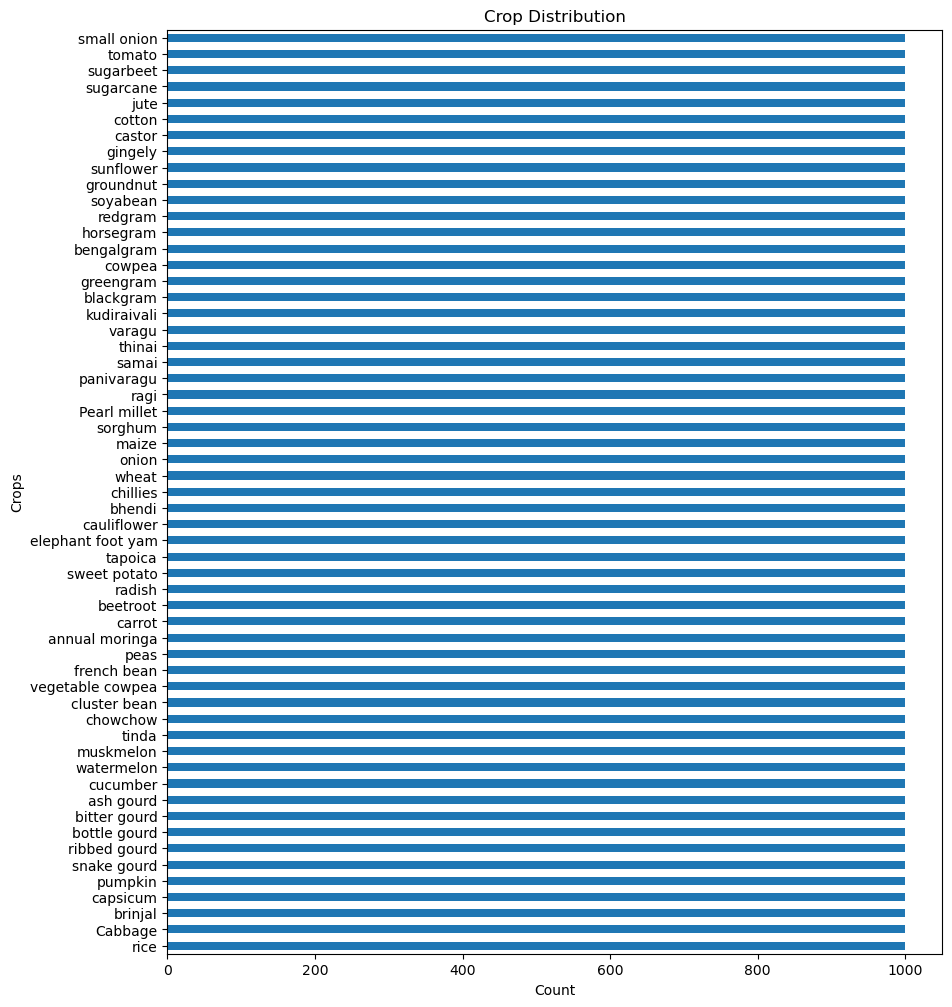

In [24]:
plt.figure(figsize=(10,12))
df['CROPS'].value_counts().plot(kind='barh')
plt.title("Crop Distribution")
plt.xlabel("Count")
plt.ylabel("Crops")
plt.show()

<Axes: >

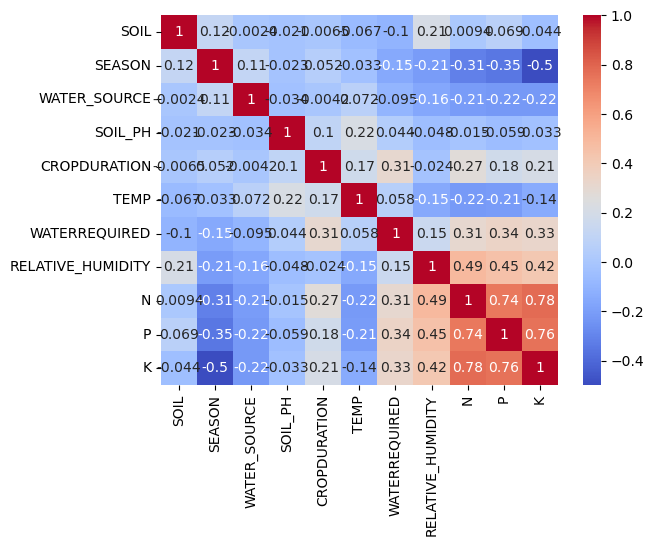

In [25]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')

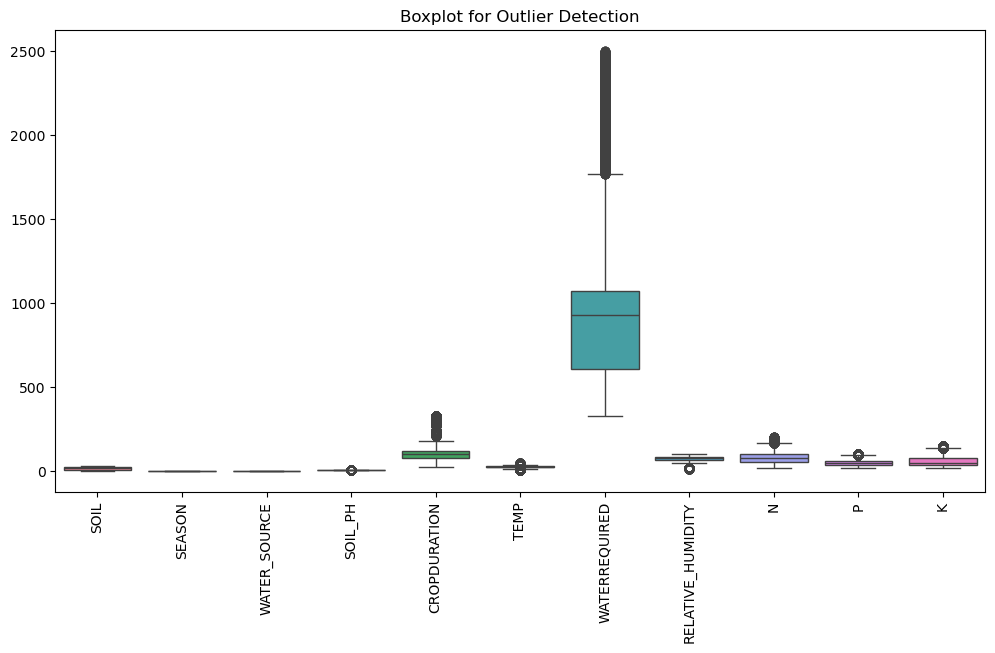

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

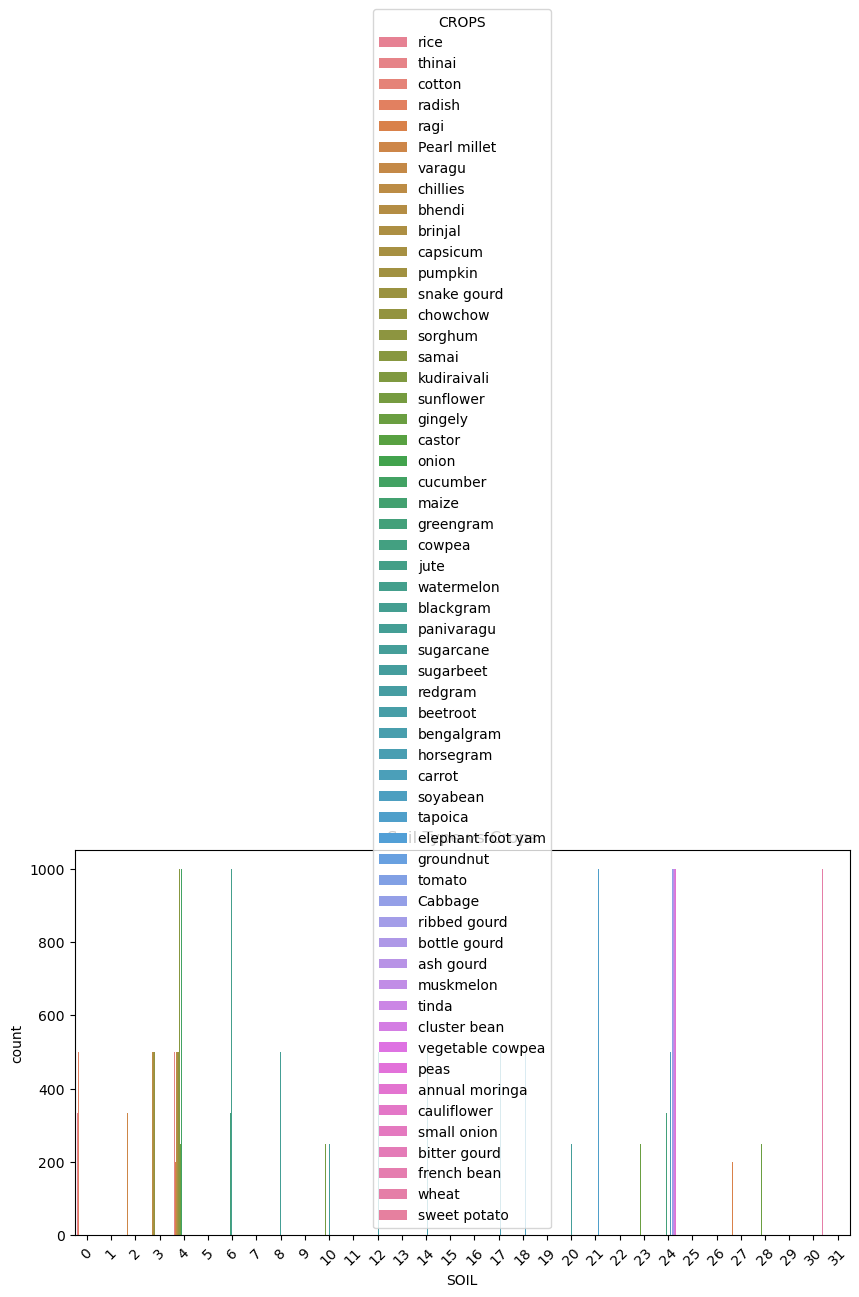

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(x='SOIL', hue='CROPS', data=df)
plt.xticks(rotation=45)
plt.title("Soil Type vs Crops")
plt.show()

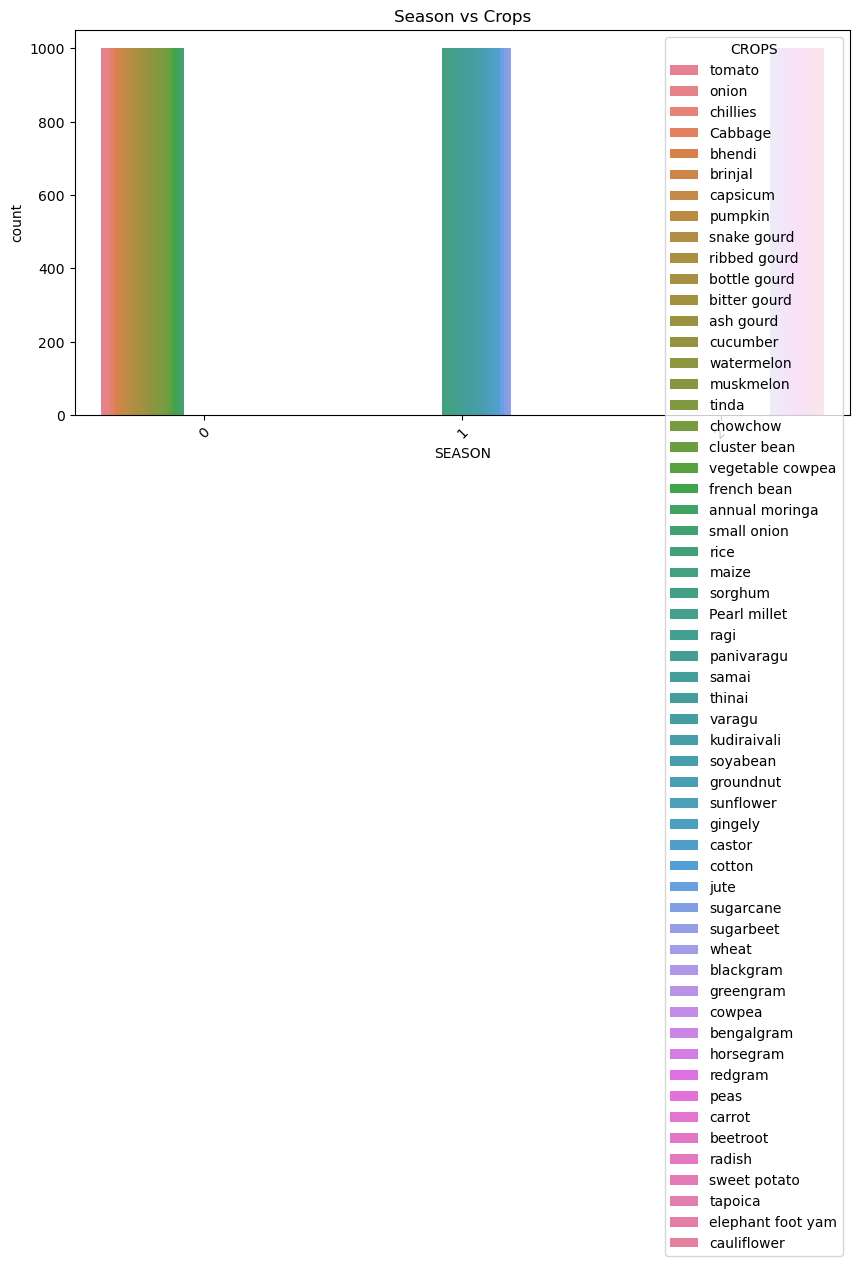

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(x='SEASON', hue='CROPS', data=df)
plt.xticks(rotation=45)
plt.title("Season vs Crops")
plt.show()

# MODEL CREATION

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
x_train

,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
22035,0,1,1,7.4,139.3,28.4,1125.0,74.5,88.5,40.6,46.4
29644,24,0,0,6.2,147.1,16.3,433.3,92.7,120.3,94.8,97.5
53246,21,2,0,6.3,292.5,25.3,1000.0,55.5,72.9,59.3,53.9
3460,4,1,0,7.5,105.0,27.2,485.1,97.9,72.2,52.2,45.8
56928,24,0,0,6.6,74.7,17.3,674.7,65.6,91.5,43.0,41.2
...,...,...,...,...,...,...,...,...,...,...,...
54343,22,2,1,6.3,240.0,30.9,1235.6,84.1,74.0,46.7,59.0
38158,24,0,0,6.3,120.0,29.1,1081.1,57.5,76.8,42.7,74.1
860,2,1,0,5.3,127.8,20.4,1592.7,60.1,95.0,42.8,59.8
15795,15,2,1,6.0,104.8,32.9,800.0,68.8,58.2,33.3,35.1


In [31]:
x_test

,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
30395,3,0,1,6.3,55.9,24.1,1631.0,95.8,142.5,64.1,95.9
23048,6,1,0,7.1,133.7,28.3,1002.9,89.6,88.5,45.0,36.8
46579,29,0,1,5.6,44.5,26.2,972.1,84.9,71.5,49.8,45.4
47826,24,2,1,6.8,64.6,17.7,1000.5,74.2,107.5,43.7,54.8
52500,30,2,0,5.8,90.8,23.9,1000.0,86.0,93.8,46.1,50.5
...,...,...,...,...,...,...,...,...,...,...,...
43611,3,0,1,6.0,150.0,19.8,1450.4,82.3,84.7,53.6,53.9
6750,24,1,0,7.0,75.0,24.1,333.4,16.9,31.6,25.0,24.9
30156,4,0,0,6.2,60.2,24.5,1499.8,97.4,122.2,66.6,82.5
19393,28,1,1,7.1,93.7,21.1,405.3,87.8,48.4,33.1,22.6


In [32]:
y_train

22035               cotton
29644              Cabbage
53246              tapoica
3460               sorghum
56928          small onion
               ...        
54343    elephant foot yam
38158            ash gourd
860                   rice
15795            horsegram
56422          small onion
Name: CROPS, Length: 45600, dtype: object

In [33]:
y_test

30395          bhendi
23048            jute
46579     french bean
47826            peas
52500    sweet potato
             ...     
43611        chowchow
6750       panivaragu
30156          bhendi
19393       sunflower
9801           varagu
Name: CROPS, Length: 11400, dtype: object

In [34]:
x_train.head()

,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
22035,0,1,1,7.4,139.3,28.4,1125.0,74.5,88.5,40.6,46.4
29644,24,0,0,6.2,147.1,16.3,433.3,92.7,120.3,94.8,97.5
53246,21,2,0,6.3,292.5,25.3,1000.0,55.5,72.9,59.3,53.9
3460,4,1,0,7.5,105.0,27.2,485.1,97.9,72.2,52.2,45.8
56928,24,0,0,6.6,74.7,17.3,674.7,65.6,91.5,43.0,41.2


In [35]:
y_train.head()

22035         cotton
29644        Cabbage
53246        tapoica
3460         sorghum
56928    small onion
Name: CROPS, dtype: object

# logistic Regression 

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score
model = LogisticRegression(max_iter=200)
model.fit(x_train,y_train)

C:\Users\An\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [37]:
y_pred=model.predict(x_test)
y_pred

array(['bhendi', 'cotton', 'french bean', ..., 'bhendi', 'sunflower',
       'varagu'], shape=(11400,), dtype=object)

In [38]:
y_test

30395          bhendi
23048            jute
46579     french bean
47826            peas
52500    sweet potato
             ...     
43611        chowchow
6750       panivaragu
30156          bhendi
19393       sunflower
9801           varagu
Name: CROPS, Length: 11400, dtype: object

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8810526315789474


In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[190   0   0 ...   0   0   0]
 [  0 125   0 ...   0   0   0]
 [  0   0 184 ...   0   0   0]
 ...
 [  0   0   0 ...  27   0   0]
 [  0   0   0 ...   0 190   0]
 [  0   0   0 ...   0   0 189]]


In [41]:
precision = precision_score(y_test, y_pred, average='weighted')
precision

0.8786474709463422

In [42]:
recall = recall_score(y_test, y_pred, average='weighted')
recall

0.8810526315789474

In [43]:
report=classification_report(y_test,y_pred)
print(report)

                   precision    recall  f1-score   support

          Cabbage       0.99      0.99      0.99       192
     Pearl millet       0.95      0.62      0.75       200
   annual moringa       0.84      0.86      0.85       214
        ash gourd       0.88      0.87      0.88       223
         beetroot       1.00      1.00      1.00       216
       bengalgram       0.77      0.69      0.73       195
           bhendi       0.96      0.98      0.97       218
     bitter gourd       0.86      0.91      0.89       188
        blackgram       0.95      0.86      0.90       187
     bottle gourd       0.80      0.87      0.83       188
          brinjal       0.93      0.88      0.90       210
         capsicum       0.95      0.91      0.93       200
           carrot       1.00      1.00      1.00       193
           castor       0.99      0.99      0.99       190
      cauliflower       0.99      0.99      0.99       198
         chillies       0.86      0.87      0.86       

# Decision Tree

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score


In [45]:
model_dt = DecisionTreeClassifier()

model_dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
y_pred_dt = model_dt.predict(x_test)
y_pred_dt

array(['bhendi', 'jute', 'french bean', ..., 'bhendi', 'sunflower',
       'varagu'], shape=(11400,), dtype=object)

In [47]:
accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy)

Accuracy: 0.9992105263157894


In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

[[192   0   0 ...   0   0   0]
 [  0 200   0 ...   0   0   0]
 [  0   0 214 ...   0   0   0]
 ...
 [  0   0   0 ... 206   0   0]
 [  0   0   0 ...   0 202   0]
 [  0   0   0 ...   0   0 194]]


In [49]:
precision = precision_score(y_test, y_pred_dt, average='weighted')
precision

0.9992166972394523

In [50]:
recall = recall_score(y_test, y_pred_dt, average='weighted')
recall

0.9992105263157894

In [51]:
report=classification_report(y_test,y_pred_dt)
print(report)

                   precision    recall  f1-score   support

          Cabbage       1.00      1.00      1.00       192
     Pearl millet       1.00      1.00      1.00       200
   annual moringa       1.00      1.00      1.00       214
        ash gourd       1.00      1.00      1.00       223
         beetroot       1.00      1.00      1.00       216
       bengalgram       1.00      1.00      1.00       195
           bhendi       1.00      1.00      1.00       218
     bitter gourd       1.00      1.00      1.00       188
        blackgram       1.00      1.00      1.00       187
     bottle gourd       1.00      0.99      1.00       188
          brinjal       1.00      1.00      1.00       210
         capsicum       1.00      1.00      1.00       200
           carrot       1.00      1.00      1.00       193
           castor       1.00      1.00      1.00       190
      cauliflower       1.00      1.00      1.00       198
         chillies       1.00      1.00      1.00       

# Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier


In [53]:
model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred_rf = model_rf.predict(x_test)
y_pred_rf

array(['bhendi', 'jute', 'french bean', ..., 'bhendi', 'sunflower',
       'varagu'], shape=(11400,), dtype=object)

In [55]:
y_test

30395          bhendi
23048            jute
46579     french bean
47826            peas
52500    sweet potato
             ...     
43611        chowchow
6750       panivaragu
30156          bhendi
19393       sunflower
9801           varagu
Name: CROPS, Length: 11400, dtype: object

In [56]:
accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)

Accuracy: 0.9999122807017544


In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[192   0   0 ...   0   0   0]
 [  0 200   0 ...   0   0   0]
 [  0   0 214 ...   0   0   0]
 ...
 [  0   0   0 ... 206   0   0]
 [  0   0   0 ...   0 202   0]
 [  0   0   0 ...   0   0 194]]


In [58]:
precision = precision_score(y_test, y_pred_rf, average='weighted')
precision

0.9999127106983143

In [59]:
recall = recall_score(y_test, y_pred_rf, average='weighted')
recall

0.9999122807017544

In [60]:
report=classification_report(y_test,y_pred_rf)
print(report)

                   precision    recall  f1-score   support

          Cabbage       1.00      1.00      1.00       192
     Pearl millet       1.00      1.00      1.00       200
   annual moringa       1.00      1.00      1.00       214
        ash gourd       1.00      1.00      1.00       223
         beetroot       1.00      1.00      1.00       216
       bengalgram       1.00      1.00      1.00       195
           bhendi       1.00      1.00      1.00       218
     bitter gourd       1.00      1.00      1.00       188
        blackgram       1.00      1.00      1.00       187
     bottle gourd       1.00      1.00      1.00       188
          brinjal       1.00      1.00      1.00       210
         capsicum       1.00      1.00      1.00       200
           carrot       1.00      1.00      1.00       193
           castor       1.00      1.00      1.00       190
      cauliflower       1.00      1.00      1.00       198
         chillies       1.00      1.00      1.00       

# KNN

In [61]:
from sklearn.neighbors import KNeighborsClassifier


In [62]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [63]:
y_pred_KNN = model_knn.predict(x_test)
y_pred_KNN

array(['bhendi', 'jute', 'french bean', ..., 'bhendi', 'sunflower',
       'varagu'], shape=(11400,), dtype=object)

In [64]:
accuracy = accuracy_score(y_test, y_pred_KNN)
print("Accuracy:", accuracy)

Accuracy: 0.9456140350877194


In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_KNN)
print(cm)

[[192   0   0 ...   0   0   0]
 [  0 178   0 ...   0   0   0]
 [  0   0 200 ...   0   0   0]
 ...
 [  0   0   0 ...  52   0   0]
 [  0   0   0 ...   0 201   0]
 [  0   0   0 ...   0   0 194]]


In [66]:
precision = precision_score(y_test, y_pred_KNN, average='weighted')
precision

0.947796853418375

In [67]:
recall = recall_score(y_test, y_pred_KNN, average='weighted')
recall


0.9456140350877194

In [68]:
report=classification_report(y_test,y_pred_KNN)
print(report)

                   precision    recall  f1-score   support

          Cabbage       1.00      1.00      1.00       192
     Pearl millet       0.95      0.89      0.92       200
   annual moringa       0.99      0.93      0.96       214
        ash gourd       0.93      0.88      0.91       223
         beetroot       1.00      1.00      1.00       216
       bengalgram       0.99      0.97      0.98       195
           bhendi       1.00      1.00      1.00       218
     bitter gourd       0.99      0.99      0.99       188
        blackgram       1.00      1.00      1.00       187
     bottle gourd       0.71      0.84      0.77       188
          brinjal       1.00      0.99      1.00       210
         capsicum       0.99      0.99      0.99       200
           carrot       1.00      1.00      1.00       193
           castor       1.00      1.00      1.00       190
      cauliflower       1.00      1.00      1.00       198
         chillies       0.96      1.00      0.98       

# SVM

In [69]:
from sklearn.svm import SVC


In [70]:
model_svm = SVC()
model_svm.fit(x_train, y_train)



,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
y_pred_svm = model_svm.predict(x_test)
y_pred_svm

array(['bhendi', 'cotton', 'beetroot', ..., 'bhendi', 'sunflower',
       'varagu'], shape=(11400,), dtype=object)

In [72]:
accuracy = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy)

Accuracy: 0.7884210526315789


In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

[[183   0   0 ...   0   0   0]
 [  0  80   0 ...   0   0   0]
 [  0   0 202 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0 171   0]
 [  0   0   0 ...   0   0 184]]


In [74]:
precision = precision_score(y_test, y_pred_svm, average='weighted')
precision

C:\Users\An\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0.7966045172389615

In [75]:
recall = recall_score(y_test, y_pred_svm, average='weighted')
recall

0.7884210526315789

In [76]:
report=classification_report(y_test,y_pred_svm)
print(report)

C:\Users\An\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\An\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\An\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                   precision    recall  f1-score   support

          Cabbage       1.00      0.95      0.98       192
     Pearl millet       0.76      0.40      0.52       200
   annual moringa       0.80      0.94      0.86       214
        ash gourd       1.00      0.23      0.37       223
         beetroot       0.49      1.00      0.66       216
       bengalgram       0.91      0.36      0.52       195
           bhendi       1.00      0.99      1.00       218
     bitter gourd       0.96      0.87      0.91       188
        blackgram       0.69      0.77      0.73       187
     bottle gourd       0.34      0.96      0.50       188
          brinjal       1.00      0.98      0.99       210
         capsicum       0.99      0.92      0.95       200
           carrot       0.99      0.99      0.99       193
           castor       0.94      1.00      0.97       190
      cauliflower       0.99      0.99      0.99       198
         chillies       0.66      1.00      0.80       

# NAIVE BAYES

In [77]:
from sklearn.naive_bayes import GaussianNB


In [78]:
model_nb = GaussianNB()

model_nb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [79]:
y_pred_nb = model_nb.predict(x_test)
y_pred_nb

array(['bhendi', 'jute', 'french bean', ..., 'bhendi', 'sunflower',
       'varagu'], shape=(11400,), dtype='<U17')

In [80]:
accuracy = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy)

Accuracy: 0.9983333333333333


In [81]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)
print(cm)

[[192   0   0 ...   0   0   0]
 [  0 197   0 ...   0   0   0]
 [  0   0 214 ...   0   0   0]
 ...
 [  0   0   0 ... 206   0   0]
 [  0   0   0 ...   0 202   0]
 [  0   0   0 ...   0   0 194]]


In [82]:
precision = precision_score(y_test, y_pred_nb, average='weighted')
precision

0.998355805479325

In [83]:
recall = recall_score(y_test, y_pred_nb, average='weighted')
recall

0.9983333333333333

In [84]:
report=classification_report(y_test,y_pred_nb)
print(report)

                   precision    recall  f1-score   support

          Cabbage       1.00      1.00      1.00       192
     Pearl millet       1.00      0.98      0.99       200
   annual moringa       1.00      1.00      1.00       214
        ash gourd       1.00      0.99      0.99       223
         beetroot       1.00      1.00      1.00       216
       bengalgram       1.00      1.00      1.00       195
           bhendi       1.00      1.00      1.00       218
     bitter gourd       1.00      1.00      1.00       188
        blackgram       1.00      1.00      1.00       187
     bottle gourd       0.99      0.99      0.99       188
          brinjal       1.00      1.00      1.00       210
         capsicum       1.00      1.00      1.00       200
           carrot       1.00      1.00      1.00       193
           castor       1.00      1.00      1.00       190
      cauliflower       1.00      1.00      1.00       198
         chillies       1.00      1.00      1.00       

# GRADIENT BOOSTING

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

In [86]:
model_gb = GradientBoostingClassifier()
model_gb.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


model_gb = GradientBoostingClassifier()
model_gb.fit(x_train, y_train)


In [87]:
y_pred_gb = model_gb.predict(x_test)
y_pred_gb

array(['bhendi', 'jute', 'french bean', ..., 'bhendi', 'sunflower',
       'varagu'], shape=(11400,), dtype=object)

In [88]:
accuracy = accuracy_score(y_test, y_pred_gb)
print("Accuracy:", accuracy)

Accuracy: 0.999561403508772


In [89]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gb)
print(cm)

[[192   0   0 ...   0   0   0]
 [  0 200   0 ...   0   0   0]
 [  0   0 213 ...   0   0   0]
 ...
 [  0   0   0 ... 206   0   0]
 [  0   0   0 ...   0 202   0]
 [  0   0   0 ...   0   0 194]]


In [90]:
precision = precision_score(y_test, y_pred_gb, average='weighted')
precision

0.9995631175481032

In [91]:
recall = recall_score(y_test, y_pred_gb, average='weighted')
recall

0.999561403508772

In [92]:
report=classification_report(y_test,y_pred_gb)
print(report)

                   precision    recall  f1-score   support

          Cabbage       1.00      1.00      1.00       192
     Pearl millet       1.00      1.00      1.00       200
   annual moringa       1.00      1.00      1.00       214
        ash gourd       1.00      1.00      1.00       223
         beetroot       1.00      1.00      1.00       216
       bengalgram       1.00      1.00      1.00       195
           bhendi       1.00      1.00      1.00       218
     bitter gourd       1.00      1.00      1.00       188
        blackgram       1.00      1.00      1.00       187
     bottle gourd       1.00      1.00      1.00       188
          brinjal       1.00      1.00      1.00       210
         capsicum       1.00      1.00      1.00       200
           carrot       1.00      1.00      1.00       193
           castor       1.00      1.00      1.00       190
      cauliflower       1.00      1.00      1.00       198
         chillies       1.00      1.00      1.00       

In [93]:
# save to pickle file
import pickle

In [94]:
import pickle

# Save trained model
pickle.dump(model_rf, open("crop_model.sav", "wb"))

# Save encoders
pickle.dump(le_Soil, open("le_Soil.pkl", "wb"))
pickle.dump(le_Season, open("le_Season.pkl", "wb"))
pickle.dump(le_Water_Source, open("le_Water_Source.pkl", "wb"))

print("Model and encoders saved successfully ✅")

Model and encoders saved successfully ✅


In [95]:
import gradio as gr
import pickle 
import numpy as np

In [96]:
#! pip install gradio

In [97]:
# Save the encoders to files
with open('le_Soil.pkl', 'wb') as f:
    pickle.dump(le_Soil, f)

with open('le_Season.pkl', 'wb') as f:
    pickle.dump(le_Season, f)

with open('le_Water_Source.pkl', 'wb') as f:
    pickle.dump(le_Water_Source, f)    

In [98]:
import pickle
import numpy as np
import gradio as gr

# ==============================
# LOAD MODEL & ENCODERS
# ==============================

model = pickle.load(open("crop_model.sav", "rb"))

le_soil = pickle.load(open("le_Soil.pkl", "rb"))
le_season = pickle.load(open("le_Season.pkl", "rb"))
le_water = pickle.load(open("le_Water_Source.pkl", "rb"))

soil_options = le_soil.classes_.tolist()
season_options = le_season.classes_.tolist()
water_options = le_water.classes_.tolist()

# ==============================
# PREDICTION FUNCTION
# ==============================

def predict_crop(soil, season, water, soil_ph, cropduration, temp, waterrequired, humidity, n, p, k):

    try:
        soil_enc = le_soil.transform([soil])[0]
        season_enc = le_season.transform([season])[0]
        water_enc = le_water.transform([water])[0]
    except:
        return "Invalid input! Please select correct values."

    # IMPORTANT: Order must match training dataset
    input_data = np.array([
        soil_enc, season_enc, water_enc,
        soil_ph, cropduration, temp, waterrequired,
        humidity, n, p, k
    ]).reshape(1, -1)

    prediction = model.predict(input_data)

    return f"🌱 Recommended Crop: {prediction[0]}"

# ==============================
# GRADIO INTERFACE
# ==============================

iface = gr.Interface(
    fn=predict_crop,
    inputs=[
        gr.Dropdown(choices=soil_options, label="Soil Type"),
        gr.Dropdown(choices=season_options, label="Season"),
        gr.Dropdown(choices=water_options, label="Water Source"),
        gr.Number(label="Soil pH"),
        gr.Number(label="Crop Duration"),
        gr.Number(label="Temperature"),
        gr.Number(label="Water Required"),
        gr.Number(label="Relative Humidity"),
        gr.Number(label="Nitrogen (N)"),
        gr.Number(label="Phosphorus (P)"),
        gr.Number(label="Potassium (K)")
    ],
    outputs="text",
    title="🌱 Crop Recommendation System",
    description="Enter soil and environmental conditions to get the best crop recommendation."
)

# ==============================
# LAUNCH
# ==============================

iface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
